---
### **Performance evalution**

포트폴리오 성과 평가
- CAGR
- Volatility
- Sharpe Ratio
- MDD
- Turnover
- 벤치마크 비교

---
##### **데이터 로드**

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Investment Factor 계산에 필요한 데이터를 input 폴더에서 불러옴
portfolio = pd.read_csv("./input/portfolio.csv", index_col=0, parse_dates=True)         # 포트폴리오
factors   = pd.read_csv("./input/factors_monthly.csv", index_col=0, parse_dates=True)   # 팩터(MKT, SMB, HML, MOM, RF) (독립변수)

In [16]:
portfolio.tail()

,Return,NAV,Trade
Date,,,
2025-04-30,0.051666,39.716165,9.318065
2025-05-31,0.068698,42.444596,15.376515
2025-06-30,0.031056,43.762754,10.362672
2025-07-31,0.040848,45.550354,10.503953
2025-08-31,-0.027382,44.303090,NaN


---
### **1. 수익률 분석**

##### Code

In [17]:
# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio['Return'], factors], axis=1, join="inner").dropna()

In [18]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

##### Output

In [19]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     117.1
Date:                Mon, 29 Sep 2025   Prob (F-statistic):           3.04e-60
Time:                        19:34:13   Log-Likelihood:                 716.60
No. Observations:                 308   AIC:                            -1423.
Df Residuals:                     303   BIC:                            -1405.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0044      0.001      3.280      0.0

---
### **2. 성과지표 계산**

##### Code

함수 정의

In [20]:
def performance_metrics(portfolio):

    portfolio_NAV    = portfolio['NAV'][1:]
    portfolio_return = portfolio['Return'][1:]
    total_trade      = portfolio['Trade'][1:]
    initial_NAV      = portfolio['NAV'].iloc[0]

    # 1. 연평균 수익률 (CAGR)
    total_months = len(portfolio_return)
    years = total_months / 12
    final_value = portfolio_NAV.iloc[-1]
    CAGR = (final_value / initial_NAV) ** (1 / years) - 1

    # 2. 월간 변동성 (Annualized Volatility)
    vol_monthly = portfolio_return.std()
    vol_annual = vol_monthly * np.sqrt(12)

    # 3. Sharpe Ratio (Rf=0 가정)
    mean_return_monthly = portfolio_return.mean()
    sharpe_ratio = (mean_return_monthly * 12) / vol_annual

    # 4. 최대 낙폭 (MDD)
    cummax_NAV = portfolio_NAV.cummax()
    drawdown = portfolio_NAV / cummax_NAV - 1
    MDD = drawdown.min()

    # 5. 월간 Turnover & 평균 Turnover
    monthly_turnover = total_trade / portfolio_NAV  # NAV 대비 총 거래액
    avg_turnover = monthly_turnover.mean()

    return {
        "CAGR": CAGR,
        "Volatility (ann.)": vol_annual,
        "Sharpe Ratio": sharpe_ratio,
        "MDD": MDD,
        "Average Turnover (monthly)": avg_turnover,
        "Turnover Series": monthly_turnover
    }

In [21]:
metrics = performance_metrics(portfolio)

##### Output

In [22]:
for k, v in metrics.items():
    if k != "Turnover Series":  # Turnover Series는 별도 DataFrame으로 보는 게 좋음
        print(f"{k}: {v:.4f}")

CAGR: 0.1592
Volatility (ann.): 0.1628
Sharpe Ratio: 0.9933
MDD: -0.2730
Average Turnover (monthly): 0.3008


---
### **3. Plot**

---
**NAV Plot**

##### Code

In [23]:
df_ret = pd.concat([portfolio['Return'].dropna(), factors['KOSPI']], axis=1, join='inner')
df_ret.columns = ['Portfolio', 'KOSPI']
df_ret.index.name = 'Date'

In [24]:
df_ret

,Portfolio,KOSPI
Date,,
2000-01-31,-0.022175,-0.081891
2000-02-29,-0.008684,-0.122367
2000-03-31,0.063178,0.039306
2000-04-30,-0.143816,-0.157444
2000-05-31,-0.111192,0.008947
...,...,...
2025-04-30,0.051666,0.030426
2025-05-31,0.068698,0.055175
2025-06-30,0.031056,0.138649


In [25]:
df_nav = (1 + df_ret).cumprod()
df_nav.columns = ['Portfolio', 'KOSPI']

In [26]:
df_nav

,Portfolio,KOSPI
Date,,
2000-01-31,0.977825,0.918109
2000-02-29,0.969333,0.805762
2000-03-31,1.030573,0.837433
2000-04-30,0.882361,0.705584
2000-05-31,0.784249,0.711897
...,...,...
2025-04-30,39.716165,2.486805
2025-05-31,42.444596,2.624014
2025-06-30,43.762754,2.987832


##### Plot

<Axes: xlabel='Date'>

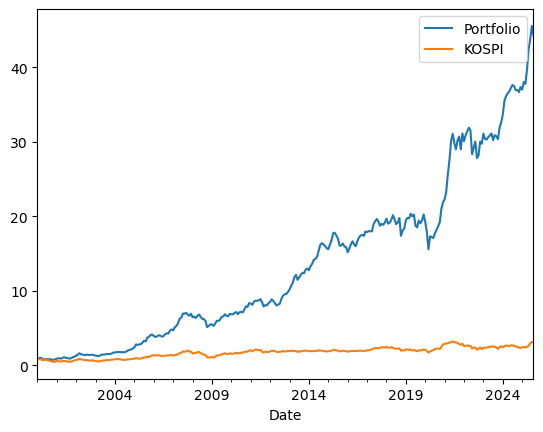

In [27]:
df_nav.plot()

---
**로그누적수익률 Plot**

<Axes: xlabel='Date'>

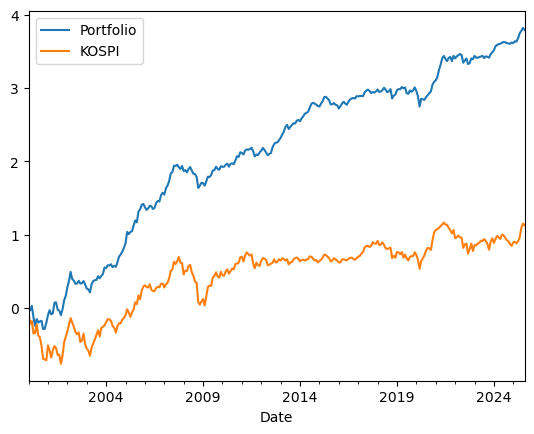

In [28]:
np.log1p(df_ret).cumsum().plot()